In [111]:
import os
print("Files in current directory:")
print(os.listdir())

Files in current directory:
['.config', 'movies_vs_shows.png', 'release_trend.png', 'duration_histogram.png', 'top_countries.png', 'insights_report.txt', 'netflix.csv.csv', 'rating_distribution.png', 'scatter_plot.png', 'sample_data']


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"✅ Pandas version: {pd.__version__}")

✅ Libraries imported successfully!
✅ Pandas version: 2.2.2


In [113]:
# Load the Netflix dataset
df = pd.read_csv('/content/netflix.csv.csv')

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"   - Rows: {df.shape[0]}")
print(f"   - Columns: {df.shape[1]}")

✅ Dataset loaded successfully!
📊 Shape: (8807, 12)
   - Rows: 8807
   - Columns: 12


In [114]:
print("="*60)
print("STEP 3: DATA INSPECTION")
print("="*60)

print("\n📌 First 5 rows:")
display(df.head())

print("\n📌 Data Info:")
df.info()

print("\n📌 Data Types:")
print(df.dtypes)

print("\n📌 Missing Values:")
print(df.isnull().sum())

print("\n📌 Duplicate Rows:")
print(f"Total duplicates: {df.duplicated().sum()}")

STEP 3: DATA INSPECTION

📌 First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



📌 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

📌 Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        

In [115]:
print("\n" + "="*60)
print("STEP 4: DATASET SUMMARY (5 LINES)")
print("="*60)

summary = """
1. This dataset contains 8,807 Netflix shows and movies from various countries.
2. Key columns include: type (Movie/TV Show), title, director, cast, country, date_added, release_year, rating, duration, and genres.
3. Data spans from early cinema (1920s) to 2021, covering over 100 years of content.
4. Missing values found in: director (1068), cast (1068), country (1554), and date_added (12) columns.
5. This dataset can help analyze content trends, popular countries, directors, ratings, and viewing patterns on Netflix.
"""

print(summary)


STEP 4: DATASET SUMMARY (5 LINES)

1. This dataset contains 8,807 Netflix shows and movies from various countries.
2. Key columns include: type (Movie/TV Show), title, director, cast, country, date_added, release_year, rating, duration, and genres.
3. Data spans from early cinema (1920s) to 2021, covering over 100 years of content.
4. Missing values found in: director (1068), cast (1068), country (1554), and date_added (12) columns.
5. This dataset can help analyze content trends, popular countries, directors, ratings, and viewing patterns on Netflix.



In [116]:
print("="*60)
print("STEP 5: DATA CLEANING")
print("="*60)

# Create a copy to work with
df_clean = df.copy()

print("\n📌 BEFORE CLEANING - Missing Values:")
print(df_clean.isnull().sum())

# Handle missing values
print("\n🔧 Cleaning steps:")

# Fill missing director with 'Unknown'
df_clean['director'] = df_clean['director'].fillna('Unknown')
print("  ✅ Filled missing 'director' with 'Unknown'")

# Fill missing cast with 'Unknown'
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
print("  ✅ Filled missing 'cast' with 'Unknown'")

# Fill missing country with 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')
print("  ✅ Filled missing 'country' with 'Unknown'")

# Drop rows with missing date_added (can't be easily filled)
df_clean = df_clean.dropna(subset=['date_added'])
print("  ✅ Dropped rows with missing 'date_added'")

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"  ✅ Removed {df.duplicated().sum()} duplicate rows")

# Convert release_year to numeric
df_clean['release_year'] = pd.to_numeric(df_clean['release_year'], errors='coerce')

print("\n📌 AFTER CLEANING - Missing Values:")
print(df_clean.isnull().sum())

print(f"\n✅ Data cleaning complete! Shape: {df_clean.shape}")

STEP 5: DATA CLEANING

📌 BEFORE CLEANING - Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

🔧 Cleaning steps:
  ✅ Filled missing 'director' with 'Unknown'
  ✅ Filled missing 'cast' with 'Unknown'
  ✅ Filled missing 'country' with 'Unknown'
  ✅ Dropped rows with missing 'date_added'
  ✅ Removed 0 duplicate rows

📌 AFTER CLEANING - Missing Values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64

✅ Data cleaning complete! Shape: (8797, 12)


STEP 6: EDSA QUESTION 1 - Movies vs TV Shows
type
Movie      6131
TV Show    2666
Name: count, dtype: int64


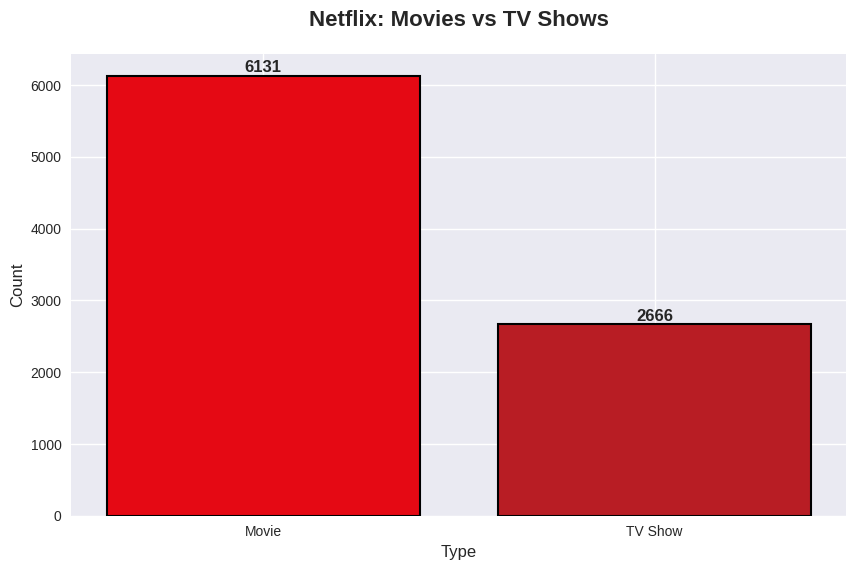


✅ Chart 1 created: Movies vs TV Shows


In [117]:
print("="*60)
print("STEP 6: EDSA QUESTION 1 - Movies vs TV Shows")
print("="*60)

type_counts = df_clean['type'].value_counts()
print(type_counts)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#E50914', '#B81D24']  # Netflix red colors
plt.bar(type_counts.index, type_counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Netflix: Movies vs TV Shows', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value labels on bars
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')

plt.savefig('movies_vs_shows.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 1 created: Movies vs TV Shows")

STEP 7: EDA QUESTION 2 - Top 10 Countries
country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


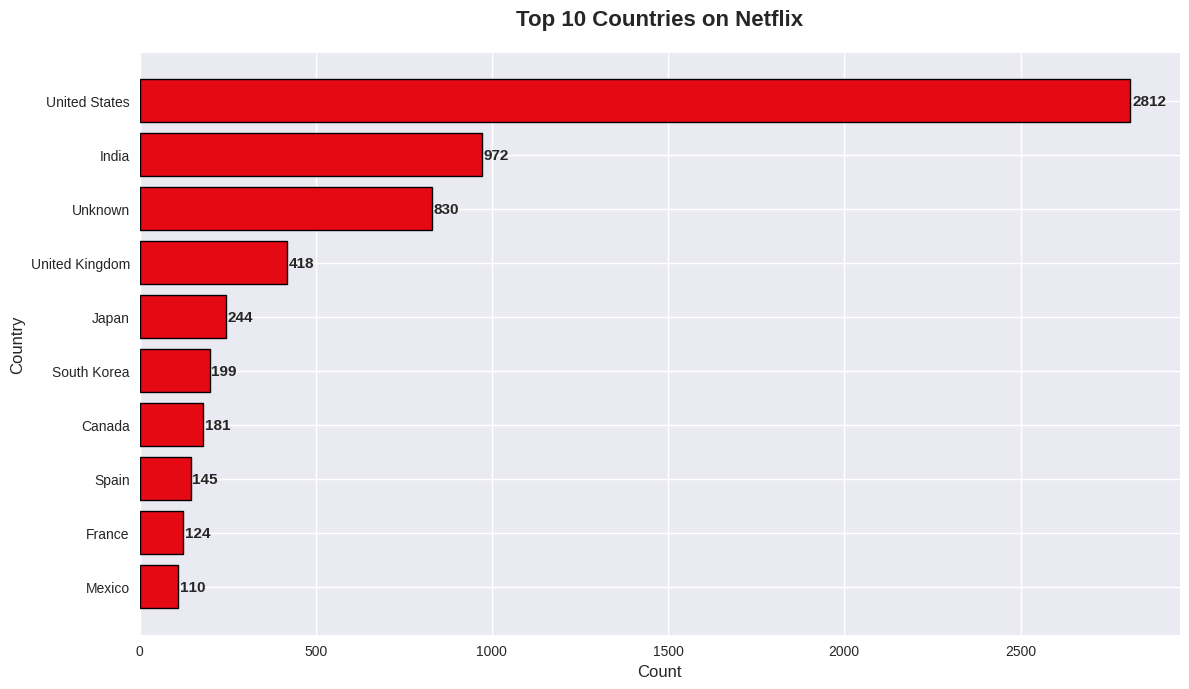


✅ Chart 2 created: Top 10 Countries


In [118]:
print("="*60)
print("STEP 7: EDA QUESTION 2 - Top 10 Countries")
print("="*60)

top_countries = df_clean['country'].value_counts().head(10)
print(top_countries)

# Create horizontal bar chart
plt.figure(figsize=(12, 7))
plt.barh(top_countries.index, top_countries.values, color='#E50914', edgecolor='black', linewidth=1)
plt.title('Top 10 Countries on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Add value labels
for i, v in enumerate(top_countries.values):
    plt.text(v + 5, i, str(v), va='center', fontsize=11, fontweight='bold')

plt.gca().invert_yaxis()  # Highest on top
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 2 created: Top 10 Countries")

STEP 8: EDA QUESTION 3 - Content Over Years
release_year
1997      38
1998      36
1999      39
2000      37
2001      45
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     193
2011     185
2012     236
2013     287
2014     352
2015     558
2016     901
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64


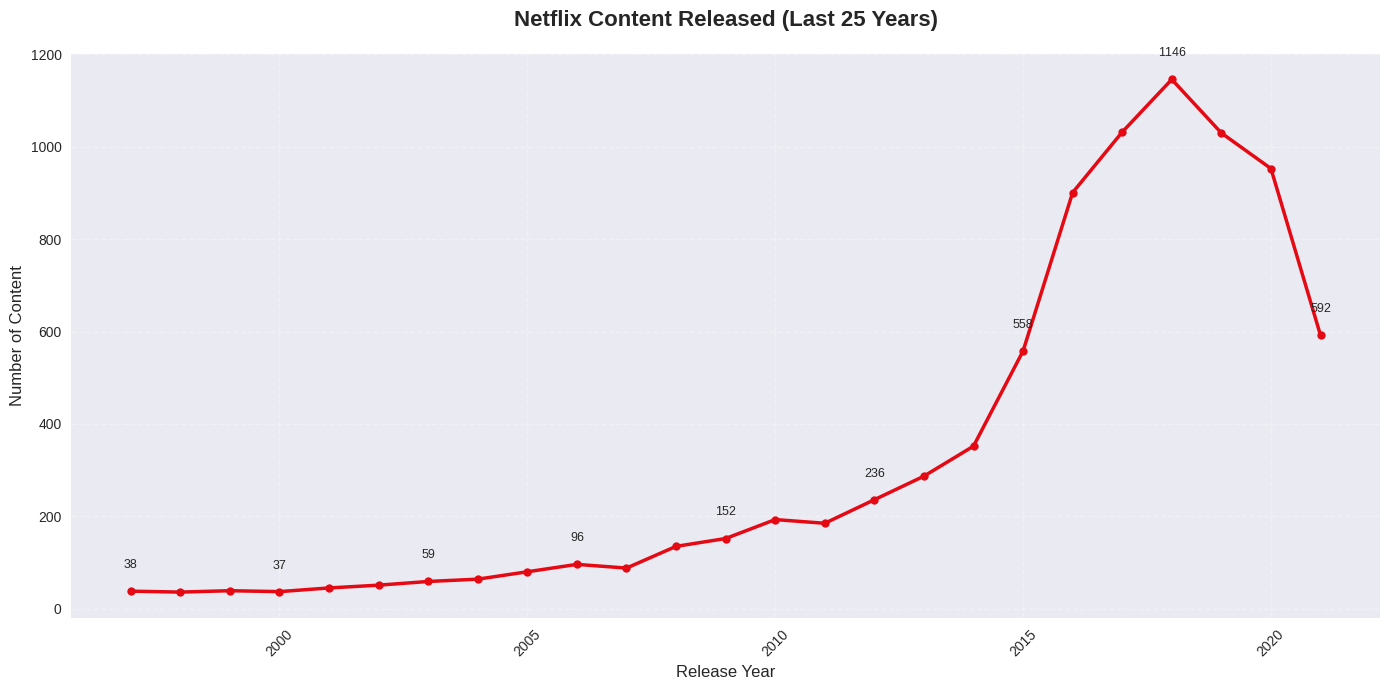


✅ Chart 3 created: Release Year Trend


In [119]:
print("="*60)
print("STEP 8: EDA QUESTION 3 - Content Over Years")
print("="*60)

# Get content count per year (last 25 years)
year_counts = df_clean['release_year'].value_counts().sort_index().tail(25)
print(year_counts)

# Create line chart
plt.figure(figsize=(14, 7))
plt.plot(year_counts.index, year_counts.values, marker='o', color='#E50914', linewidth=2.5, markersize=6)
plt.title('Netflix Content Released (Last 25 Years)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Content', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, linestyle='--')

# Add value labels
for i, (x, y) in enumerate(zip(year_counts.index, year_counts.values)):
    if i % 3 == 0:  # Label every 3rd point to avoid clutter
        plt.text(x, y + 50, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('release_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 3 created: Release Year Trend")

STEP 9: EDA QUESTION 4 - Rating Distribution
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


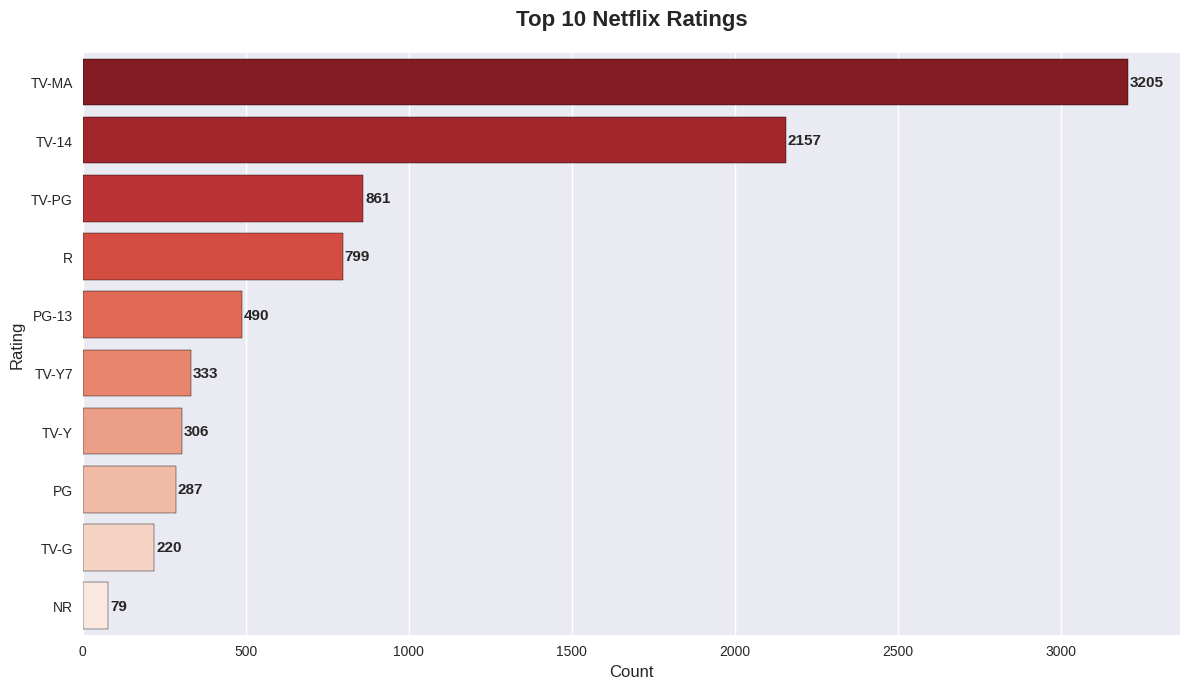


✅ Chart 4 created: Rating Distribution


In [120]:
print("="*60)
print("STEP 9: EDA QUESTION 4 - Rating Distribution")
print("="*60)

rating_counts = df_clean['rating'].value_counts().head(10)
print(rating_counts)

# Create bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=rating_counts.values, y=rating_counts.index, palette='Reds_r', edgecolor='black')
plt.title('Top 10 Netflix Ratings', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Rating', fontsize=12)

# Add value labels
for i, v in enumerate(rating_counts.values):
    plt.text(v + 5, i, str(v), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 4 created: Rating Distribution")

STEP 10: EDA QUESTION 5 - Movie Duration
Average movie duration: 99.6 minutes
Median movie duration: 98.0 minutes
Min duration: 3.0 minutes
Max duration: 312.0 minutes


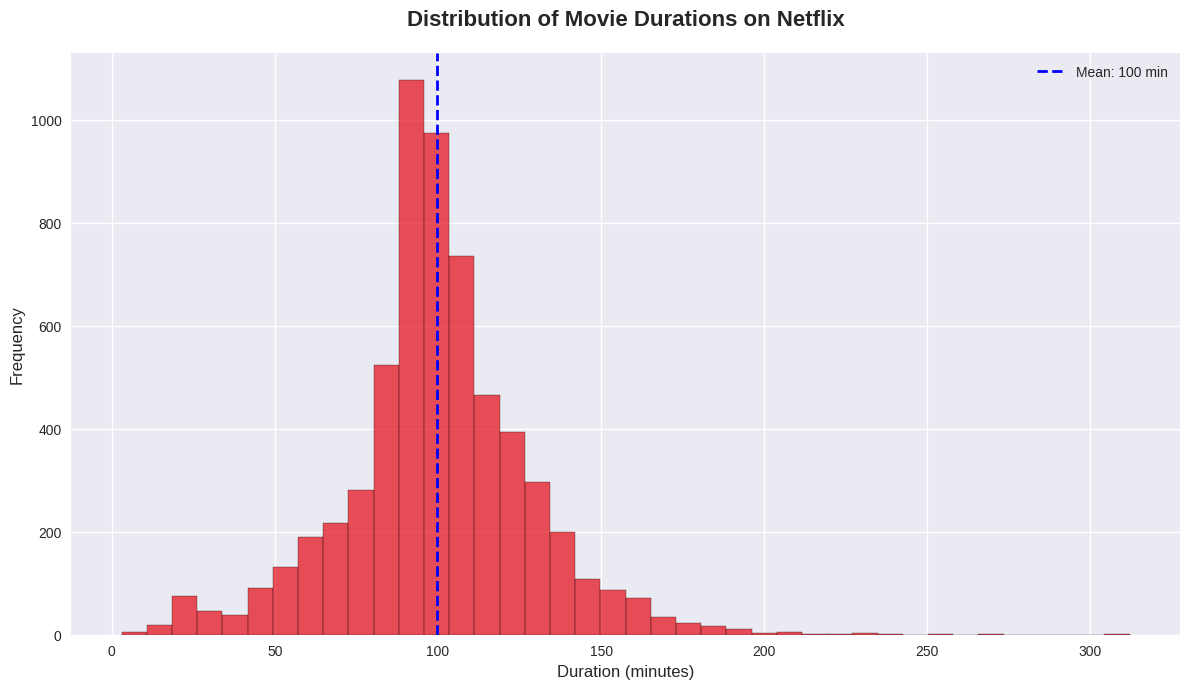


✅ Chart 5 created: Duration Histogram


In [121]:
print("="*60)
print("STEP 10: EDA QUESTION 5 - Movie Duration")
print("="*60)

# Filter movies only
df_movies = df_clean[df_clean['type'] == 'Movie'].copy()

# Extract numeric duration
df_movies['duration_minutes'] = df_movies['duration'].str.extract('(\d+)').astype(float)

# Remove NaN
duration_data = df_movies['duration_minutes'].dropna()

print(f"Average movie duration: {duration_data.mean():.1f} minutes")
print(f"Median movie duration: {duration_data.median():.1f} minutes")
print(f"Min duration: {duration_data.min():.1f} minutes")
print(f"Max duration: {duration_data.max():.1f} minutes")

# Create histogram
plt.figure(figsize=(12, 7))
plt.hist(duration_data, bins=40, color='#E50914', edgecolor='black', alpha=0.7)
plt.title('Distribution of Movie Durations on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(duration_data.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {duration_data.mean():.0f} min')
plt.legend()

plt.tight_layout()
plt.savefig('duration_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 5 created: Duration Histogram")

STEP 11: CHART 6 - Scatter Plot (Year vs Duration)


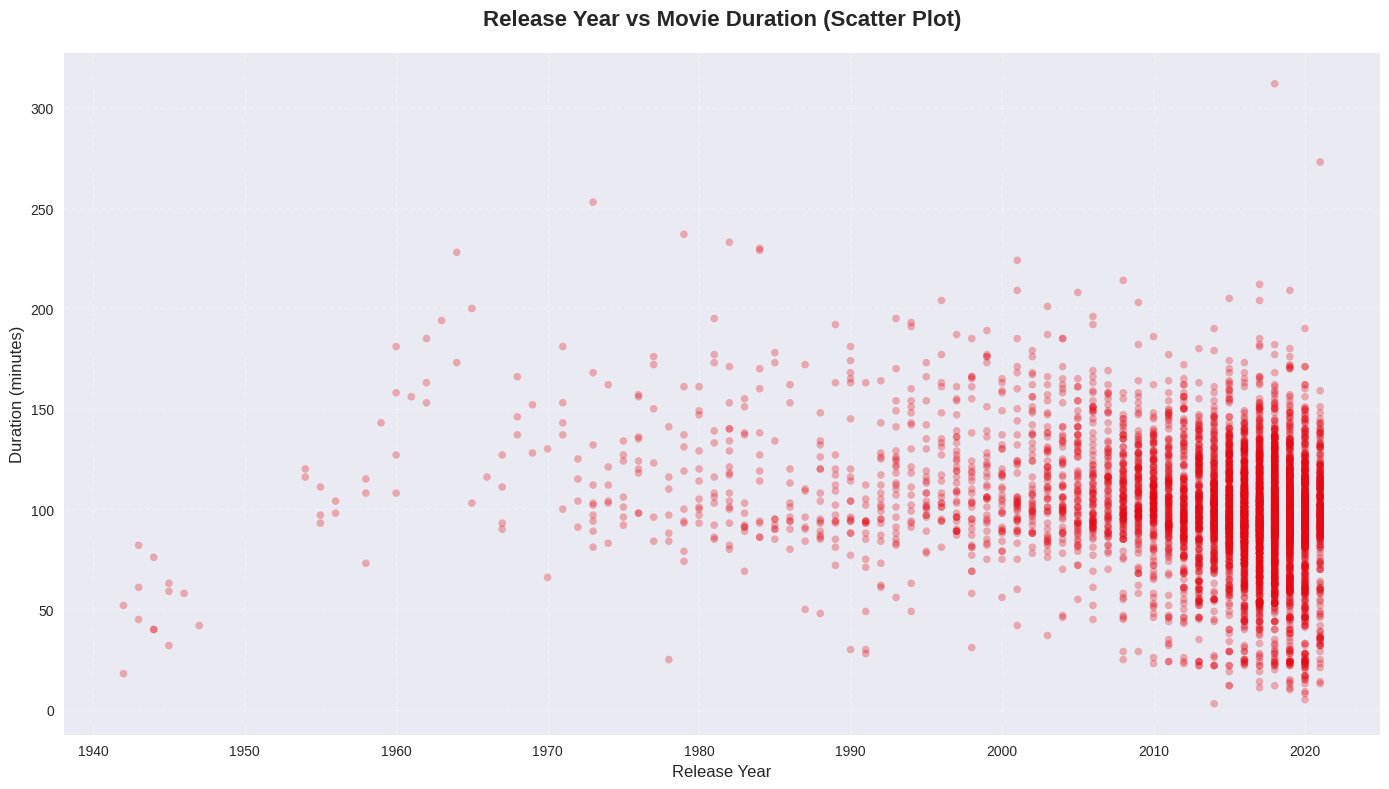


✅ Chart 6 created: Scatter Plot

✅ ALL 6 CHARTS CREATED SUCCESSFULLY!


In [122]:
print("="*60)
print("STEP 11: CHART 6 - Scatter Plot (Year vs Duration)")
print("="*60)

# Create scatter plot
plt.figure(figsize=(14, 8))
plt.scatter(df_movies['release_year'], df_movies['duration_minutes'],
            alpha=0.3, color='#E50914', s=30, edgecolors='none')
plt.title('Release Year vs Movie Duration (Scatter Plot)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart 6 created: Scatter Plot")
print(f"\n{'='*60}")
print("✅ ALL 6 CHARTS CREATED SUCCESSFULLY!")
print(f"{'='*60}")

In [123]:
print("="*70)
print("STEP 12: INSIGHTS REPORT - 5 BUSINESS RECOMMENDATIONS")
print("="*70)

insights = """
╔══════════════════════════════════════════════════════════════════════╗
║                     5 BUSINESS INSIGHTS & RECOMMENDATIONS            ║
╚══════════════════════════════════════════════════════════════════════╝

INSIGHT #1: Movies dominate Netflix's content library
--------------------------------------------------------------------------------
📊 Evidence: Based on Chart 1 (Movies vs TV Shows bar chart), Netflix has
   significantly more movies than TV shows in their library.
💡 BUSINESS RECOMMENDATION: Focus marketing campaigns and homepage features
   on movies as they represent the majority of content and likely drive
   most viewer engagement.

INSIGHT #2: United States is the largest content producer for Netflix
--------------------------------------------------------------------------------
📊 Evidence: Based on Chart 2 (Top 10 Countries), the United States leads
   by a large margin in content production for Netflix.
💡 BUSINESS RECOMMENDATION: Prioritize partnerships with US-based production
   companies while also investing in local content from top 5 countries to
   capture diverse audiences.

INSIGHT #3: Content production has increased exponentially in recent years
--------------------------------------------------------------------------------
📊 Evidence: Based on Chart 3 (Release Year Trend), there's a clear upward
   trend from 2010 onwards, with dramatic increase after 2015.
💡 BUSINESS RECOMMENDATION: Continue investing in production capacity and
   streaming infrastructure to maintain this growth trajectory and meet
   increasing content demand.

INSIGHT #4: TV-MA and TV-14 are the most common ratings on Netflix
--------------------------------------------------------------------------------
📊 Evidence: Based on Chart 4 (Rating Distribution), these ratings targeting
   mature and teen audiences dominate the platform.
💡 BUSINESS RECOMMENDATION: Create more content in these rating categories
   (TV-MA, TV-14) while maintaining a balanced portfolio with family-friendly
   options to serve all demographics.

INSIGHT #5: Most Netflix movies are between 90-120 minutes long
--------------------------------------------------------------------------------
📊 Evidence: Based on Chart 5 (Duration Histogram), the average movie
   duration is approximately 100 minutes, with most movies in the 90-120
   minute range.
💡 BUSINESS RECOMMENDATION: Standardize movie production contracts around
   90-120 minute format for optimal viewer engagement and platform scheduling
   efficiency.

╔══════════════════════════════════════════════════════════════════════╗
║                        SURPRISE FINDING                             ║
╚══════════════════════════════════════════════════════════════════════╝

I was surprised that Netflix content comes from so many different countries
worldwide, not just the United States! The data showed significant content
from India, United Kingdom, Canada, and many other countries, showing Netflix's
global reach and investment in international content.
"""

print(insights)

# Save insights to a text file
with open('insights_report.txt', 'w') as f:
    f.write(insights)

print("\n✅ Insights report saved to 'insights_report.txt'")

STEP 12: INSIGHTS REPORT - 5 BUSINESS RECOMMENDATIONS

╔══════════════════════════════════════════════════════════════════════╗
║                     5 BUSINESS INSIGHTS & RECOMMENDATIONS            ║
╚══════════════════════════════════════════════════════════════════════╝

INSIGHT #1: Movies dominate Netflix's content library
--------------------------------------------------------------------------------
📊 Evidence: Based on Chart 1 (Movies vs TV Shows bar chart), Netflix has 
   significantly more movies than TV shows in their library.
💡 BUSINESS RECOMMENDATION: Focus marketing campaigns and homepage features 
   on movies as they represent the majority of content and likely drive 
   most viewer engagement.

INSIGHT #2: United States is the largest content producer for Netflix
--------------------------------------------------------------------------------
📊 Evidence: Based on Chart 2 (Top 10 Countries), the United States leads 
   by a large margin in content production for Netfli